# Compare FLORIS, RANS, LES

In [1]:
import matplotlib.pyplot as plt
from matplotlib import rcParams
from mpl_toolkits.axes_grid1 import make_axes_locatable


import numpy as np 
import pathlib
import pandas as pd
import scipy as sp
import pickle
import sys

import floris.layout_visualization as layoutviz
from floris import (
    FlorisModel,
    TimeSeries,
    WindRose,
    WindTIRose,
)
from floris.flow_visualization import visualize_cut_plane

library_path = '/gpfs/gyalla/Advanced_Controls/Floris/'
if library_path not in sys.path:
    sys.path.append(library_path)
import calibrate_floris as cf

import floris
print(f"The source file for the floris library is located at: {floris.__file__}")
print(floris.__version__)

The source file for the floris library is located at: /projects/wind_uq/python/env/windconda2/lib/python3.11/site-packages/floris/__init__.py
4.1.1


In [2]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import time
from scipy.integrate import solve_ivp
from scipy.optimize import fsolve
from mpl_toolkits.axes_grid1 import make_axes_locatable

import pickle

In [3]:
import sys, os
curdir = os.getcwd()
extradirs = ['../', '../../',
             '../../SANDwake3D',
             os.path.dirname(curdir),
            ]
for x in extradirs: sys.path.insert(1, x)

In [4]:
def loadpickle(picklefile):
    pfile          = open(picklefile, 'rb')
    ds             = pickle.load(pfile)
    pfile.close()
    return ds

find_nearest = lambda a, a0: np.abs(np.array(a) - a0).argmin()

In [5]:
# Load RANS solution
loadpklfile = 'Phi_LowWS_LowTI.pkl'
db = loadpickle(loadpklfile)
params = db['params']
xvec   = db['xvec']
phi    = db['phi']

## SETUP FLORIS CASES 

In [6]:
#Define list of cases 
cases = [
    "LowWS_LowTI_Baseline",
]

#Specify setup files to be generated for each case
setup_files = {}
setup_files[cases[0]] = 'LowWS_LowTI_Baseline_emgauss.yaml'

#Specify original version of floris yaml that will be modified
input_setup_file = "./baseline_emgauss.yaml"

#Specify shared parameters between each case
wind_speed_factor = 0.9760704004728211
wind_speed = 6.5
setup_params  = {
    'flow_field.wind_speeds': [wind_speed*wind_speed_factor],
    'flow_field.air_density': 1.2456,
    'flow_field.wind_directions': [270,],
    'flow_field.turbulence_intensities': [0.036,],
    #'flow_field.wind_veer': 8.94,
    #'flow_field.wind_shear': 0.16,
    'flow_field.wind_veer': 7.92,
    'flow_field.wind_shear': 0.142,
    'farm.turbine_type': ['iea_15MW',],
    'farm.turbine_library_path': '/gpfs/gyalla/Advanced_Controls/Floris/turbine_library',
    #'/ascldap/users/gyalla/GPFS/Advanced_Controls/Floris/turbine_library',
}

layouts  = {}

In [7]:
#Layout for baseline 6D 45
T00_base_position               = [2280.0, 1000.0, 0.0]
layout_x  = [T00_base_position[0],]
layout_y  = [T00_base_position[1],]
layouts[cases[0]] = (layout_x,layout_y)

In [8]:

floris_models = {}
for case in cases:
    setup_params["farm.layout_x"] = layouts[case][0]
    setup_params["farm.layout_y"] = layouts[case][1]
    cf.setup_floris_yaml(input_setup_file,setup_params,output_file=setup_files[case])
    floris_model = FlorisModel(setup_files[case],)
    floris_models[case] = floris_model
    print("Setup floris model for " + case + " with configuration file: ", floris_model.configuration)


floris.logging_manager.LoggingManager WARNING Running wake_induced_mixing model with mixing contributions from the atmospheric turbulence intensity has not been vetted. To avoid this warning, set atmospheric_ti_gain=0. in the FLORIS input yaml.


Setup floris model for LowWS_LowTI_Baseline with configuration file:  LowWS_LowTI_Baseline_emgauss.yaml


### Run calibrated model

In [9]:
turbine_powers = {}
for case in cases:
    floris_model = floris_models[case]
    floris_model.run()
    turbine_powers[case] = floris_model.get_turbine_powers()/1000


In [10]:
prob_hi = [6720,2000,960]
Nx = 500
Ny = 250
Nz = 250
fmodel = floris_models[cases[0]]
horizontal_plane = fmodel.calculate_horizontal_plane(
    x_resolution=Nx,
    y_resolution=Ny,
    height=150.0,
    x_bounds=(0,prob_hi[0]),
    y_bounds=(0,prob_hi[1]),
)
x1 = horizontal_plane.df['x1']
x2 = horizontal_plane.df['x2']
u = horizontal_plane.df['u']

# Plot the flow field with rotor
#fig, ax = plt.subplots(figsize=(8,6),dpi=125)
#visualize_cut_plane(
#horizontal_plane,
#ax=ax,
#label_contours=False,
#cmap='coolwarm',
#color_bar = True
#)



floris.logging_manager.LoggingManager WARNING Running wake_induced_mixing model with mixing contributions from the atmospheric turbulence intensity has not been vetted. To avoid this warning, set atmospheric_ti_gain=0. in the FLORIS input yaml.


## Compare the XY plane

In [11]:
turbD  = 240
turbhh = 150
LES_turbx = 2280
LES_turby = 1000
RANS_turbx = 120

maxV=2.5
maxL=0.5
maxP=0.01
vlevels={'u':{'levels':np.linspace(0,8,81), 'cbarticks':np.arange(0,8,1)},
         'v':{'levels':np.linspace(-maxV,maxV,41), 'cbarticks':np.arange(-maxV, maxV+1E-5,maxV/5)},
         'w':{'levels':np.linspace(-maxL,maxL,41), 'cbarticks':np.arange(-maxL, maxL+1E-5,maxL/5)}, 
         'k':{'levels':np.linspace(0,2,41), 'cbarticks':np.arange(0, 2,2.0/5)}, 
         'p':{'levels':np.linspace(-maxP,maxP,41), 'cbarticks':np.arange(-maxP, maxP+1E-5,maxP/5)}, 
        }

plotv = 'u'

In [12]:
# Load the LES data
XY_wake = loadpickle('XYplanes/XY_wake.pkl')

Text(0.5, 1.0, 'FLORIS U velocity')

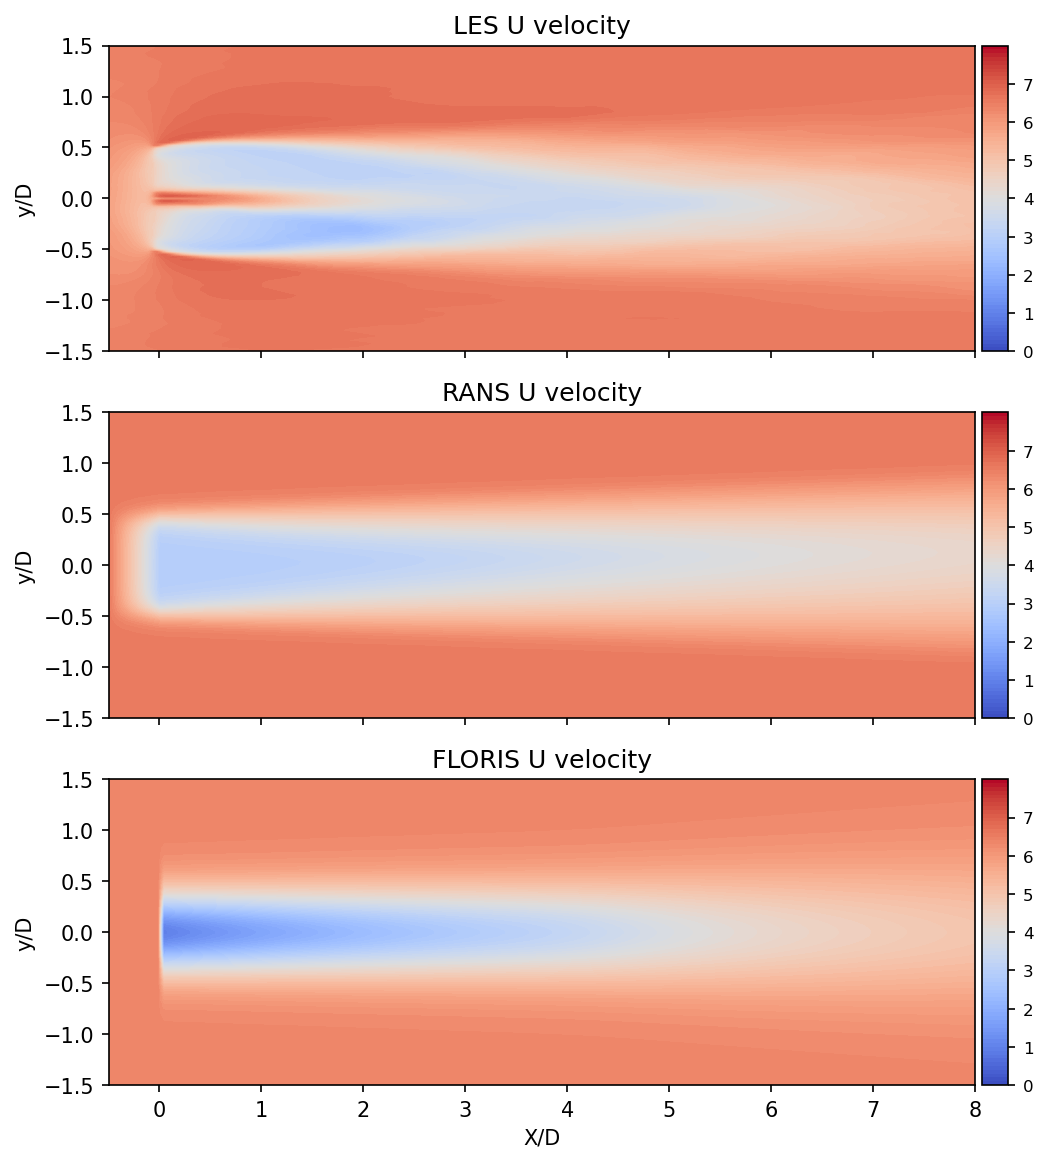

In [13]:
zvec=params['zm'][0,:]
yvec=params['ym'][:,0]
xm, ym = np.meshgrid(xvec, yvec)
izRANS = find_nearest(zvec, turbhh)

c={}
fig, axs = plt.subplots(3,1,figsize=(10,9), dpi=150, sharex=True)
# Plot LES
c[0] = axs[0].contourf((XY_wake['x'][1,:,:]-LES_turbx)/turbD, (XY_wake['y'][1,:,:]-LES_turby)/turbD, XY_wake['velocityx_avg'][1,:,:], levels=vlevels[plotv]['levels'], cmap='coolwarm')
# Plot RANS
c[1] = axs[1].contourf((xm-RANS_turbx)/turbD, ym/turbD, phi[plotv][:,:,izRANS].transpose(), levels=vlevels[plotv]['levels'], cmap='coolwarm')
# Plot FLORIS
cut_plane = horizontal_plane
# Plot the cut-through
c[2] = axs[2].tricontourf((cut_plane.df.x1-LES_turbx)/turbD,
                          (cut_plane.df.x2-LES_turby)/turbD,
                          cut_plane.df.u,
                          #vmin=min_speed, #vmax=max_speed,
                          levels=vlevels[plotv]['levels'],
                          cmap='coolwarm',
                         )

for ix, ax in enumerate(axs[:]):
    ax.set_xlim([-0.5,8])
    ax.set_ylim([-1.5, 1.5])
    ax.set_aspect('equal')
    
    divider = make_axes_locatable(axs[ix])
    cax = divider.append_axes("right", size="3%", pad=0.05)
    cbar=fig.colorbar(c[ix], ax=axs[ix], cax=cax, ticks = matplotlib.ticker.FixedLocator(vlevels[plotv]['cbarticks']))
    cbar.ax.tick_params(labelsize=8)
    
    ax.set_ylabel('y/D')
    
axs[2].set_xlabel('X/D')
axs[0].set_title('LES U velocity')
axs[1].set_title('RANS U velocity')
axs[2].set_title('FLORIS U velocity')

187 238.3166332665328
205 480.72144288577147
241 965.5310621242484
276 1436.8737474949899
312 1921.6833667334668


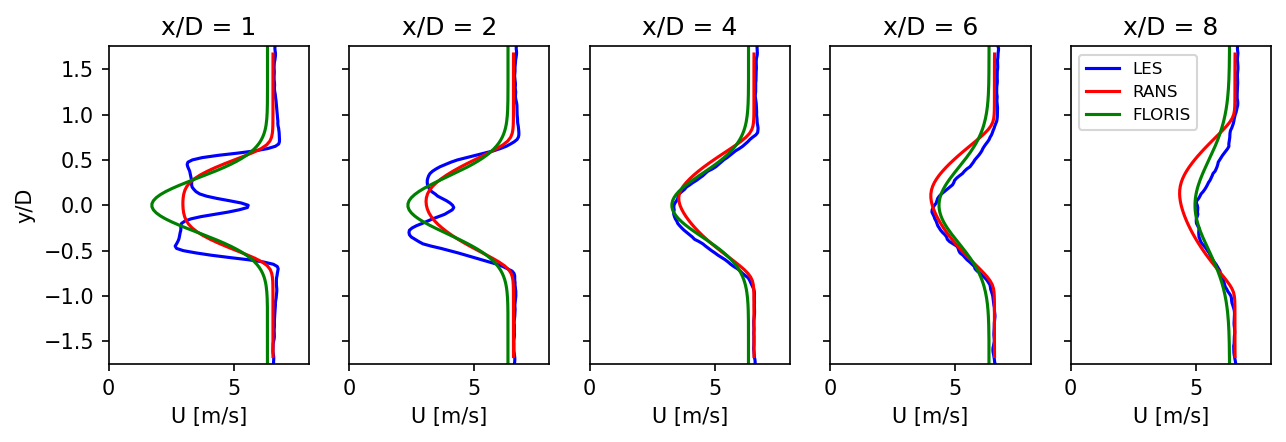

In [14]:
# Plot XY wake profiles
xvecLES = XY_wake['x'][1,0,:]
yvecLES = XY_wake['y'][1,:,0]


xmF = np.array(cut_plane.df.x1).reshape((Ny, Nx))
ymF = np.array(cut_plane.df.x2).reshape((Ny, Nx))
umF = np.array(cut_plane.df.u).reshape((Ny, Nx))
xvecFLO = xmF[0,:]
yvecFLO = ymF[:,0]

xplot = [1, 2, 4, 6, 8]
fig, axs = plt.subplots(1,len(xplot),figsize=(len(xplot)*2,2.75), dpi=150, sharey=True)
for ix, x in enumerate(xplot):
    axs[ix].set_title(f'x/D = {x}')
    
    # Plot LES
    ixLES = find_nearest((xvecLES-LES_turbx)/turbD, x)
    u_LES = XY_wake['velocityx_avg'][1,:,ixLES]
    axs[ix].plot(u_LES, (yvecLES-LES_turby)/turbD, 'b-', label='LES')

    # Plot RANS
    ixRANS = find_nearest((xvec-RANS_turbx)/turbD, x)
    izRANS = find_nearest(zvec, turbhh)
    u_RANS = phi['u'][ixRANS,:,izRANS]
    axs[ix].plot(u_RANS, yvec/turbD, 'r-', label='RANS')

    # Plot FLORIS
    ixFLO = find_nearest((xvecFLO-LES_turbx)/turbD, x)
    print(ixFLO, xvecFLO[ixFLO]-LES_turbx)
    u_FLO = umF[:,ixFLO]
    axs[ix].plot(u_FLO, (yvecFLO-LES_turby)/turbD, 'g-', label='FLORIS')

for ax in axs:
    ax.set_xlim([0,8])
    ax.set_ylim([-1.75, 1.75])
    ax.set_xlabel('U [m/s]')
axs[0].set_ylabel('y/D')
axs[-1].legend(fontsize=8)

## Compare the YZ planes

In [15]:
plotdict = [
    # x/D = 2
    {'LES_YZfile':'YZplanes/YZ_wake3.pkl', 
     'LES_turbx':LES_turbx, 
     'LES_turby':LES_turby, 
     'LES_iplane':0,  
     'LES_plotvar':'velocityx_avg',
     'RANS_turbx':RANS_turbx,
     'RANS_plotvar':'u',
     'turbD':turbD,
     'turbhh':turbhh,
     'savefig':'LowWS_LowTI_U_YZ_2D.png',
    },
    
    # x/D = 4
    {'LES_YZfile':'YZplanes/YZ_wake3.pkl', 
     'LES_turbx':LES_turbx, 
     'LES_turby':LES_turby, 
     'LES_iplane':4,  
     'LES_plotvar':'velocityx_avg',
     'RANS_turbx':RANS_turbx,
     'RANS_plotvar':'u',
     'turbD':turbD,
     'turbhh':turbhh,
     'savefig':'',
    },

    # x/D = 6
    {'LES_YZfile':'YZplanes/YZ_wake4.pkl', 
     'LES_turbx':LES_turbx, 
     'LES_turby':LES_turby, 
     'LES_iplane':1,  
     'LES_plotvar':'velocityx_avg',
     'RANS_turbx':RANS_turbx,
     'RANS_plotvar':'u',
     'turbD':turbD,
     'turbhh':turbhh,
     'savefig':'',
    },

    # x/D = 8
    {'LES_YZfile':'YZplanes/YZ_wake4.pkl', 
     'LES_turbx':LES_turbx, 
     'LES_turby':LES_turby, 
     'LES_iplane':3,  
     'LES_plotvar':'velocityx_avg',
     'RANS_turbx':RANS_turbx,
     'RANS_plotvar':'u',
     'turbD':turbD,
     'turbhh':turbhh,
     'savefig':'',
    },

]

floris.logging_manager.LoggingManager WARNING Running wake_induced_mixing model with mixing contributions from the atmospheric turbulence intensity has not been vetted. To avoid this warning, set atmospheric_ti_gain=0. in the FLORIS input yaml.
floris.logging_manager.LoggingManager WARNING Running wake_induced_mixing model with mixing contributions from the atmospheric turbulence intensity has not been vetted. To avoid this warning, set atmospheric_ti_gain=0. in the FLORIS input yaml.
floris.logging_manager.LoggingManager WARNING Running wake_induced_mixing model with mixing contributions from the atmospheric turbulence intensity has not been vetted. To avoid this warning, set atmospheric_ti_gain=0. in the FLORIS input yaml.
floris.logging_manager.LoggingManager WARNING Running wake_induced_mixing model with mixing contributions from the atmospheric turbulence intensity has not been vetted. To avoid this warning, set atmospheric_ti_gain=0. in the FLORIS input yaml.


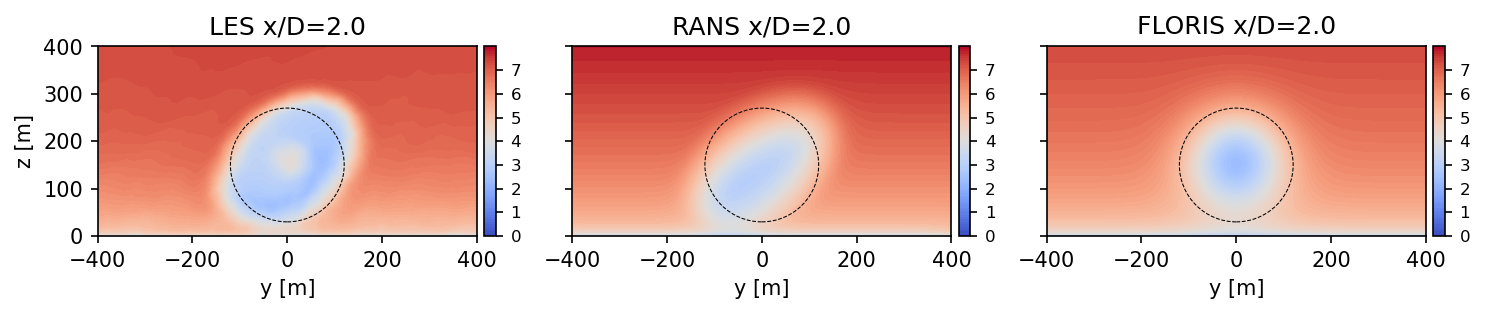

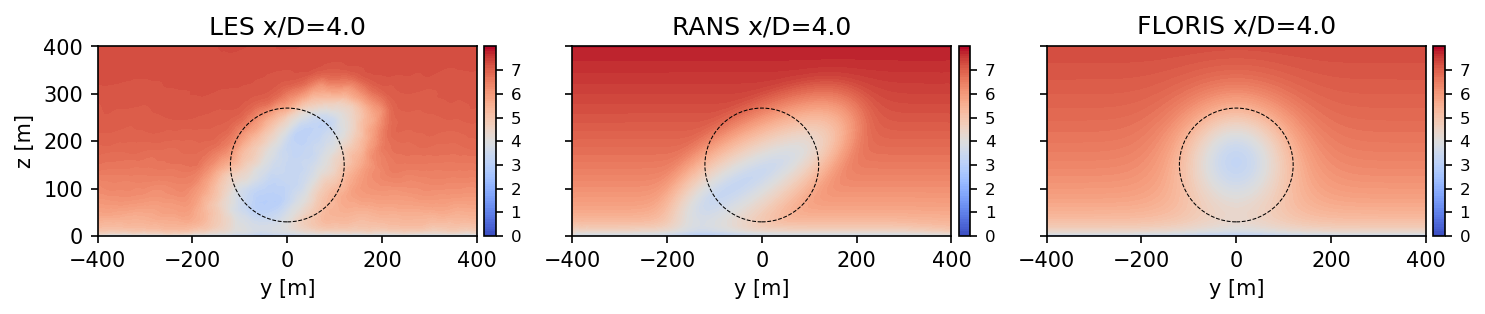

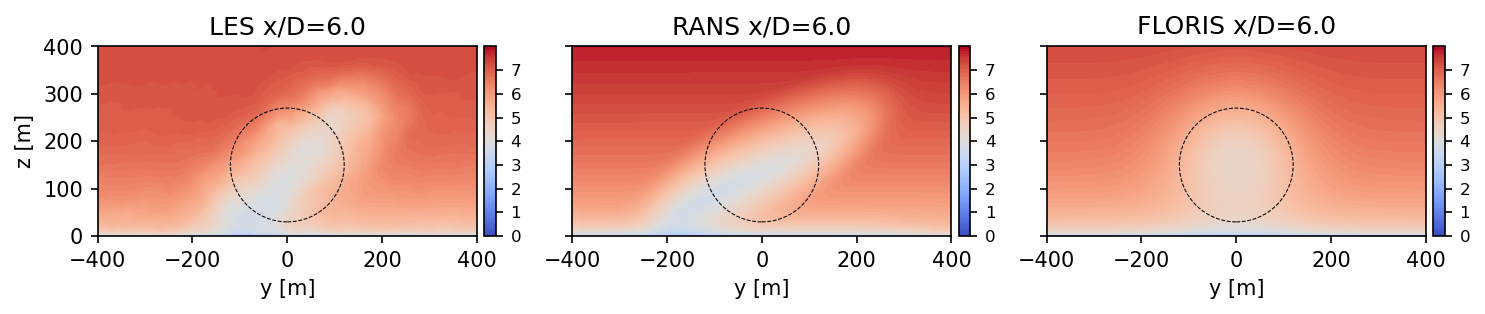

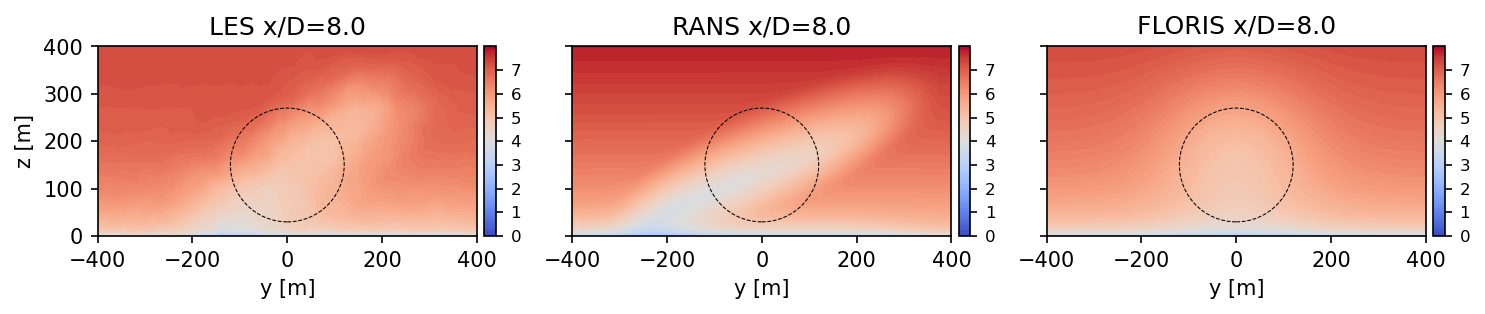

In [16]:
for plotd in plotdict:
    fig, axs = plt.subplots(1,3,figsize=(10,2.75), dpi=150, sharey=True)
    plotv = plotd['RANS_plotvar']
    turbD = plotd['turbD']
    turbhh= plotd['turbhh']
    c ={}
    # --- Do the LES plot ---
    ix      = 0
    YZ_wake = loadpickle(plotd['LES_YZfile'])
    ii      = plotd['LES_iplane']
    xplot=np.mean((YZ_wake['x'][[ii],:,:]-plotd['LES_turbx']))/turbD
    #print(xplot)
    
    c[ix]=axs[ix].contourf(-(YZ_wake['y'][ii,:,:]-plotd['LES_turby']), 
                            YZ_wake['z'][ii,:,:],
                            YZ_wake['velocityx_avg'][ii,:,:],
                            levels=vlevels[plotv]['levels'], cmap='coolwarm')
    
    # --- Do the RANS plot ---
    ix=1
    x=plotd['RANS_turbx']+turbD*xplot
    ixRANS = find_nearest(xvec, x)
    #print((xvec[ixRANS]-plotd['RANS_turbx'])/turbD)
    c[ix]=axs[ix].contourf(params['ym'], params['zm'], phi[plotv][ixRANS,:,:], levels=vlevels[plotv]['levels'], cmap='coolwarm')

    # --- Do the FLORIS plot ---
    ix=2
    cross_plane = fmodel.calculate_cross_plane(
        y_resolution=250,
        z_resolution=250,
        downstream_dist=xplot*turbD+plotd['LES_turbx'],
        y_bounds=(0,prob_hi[1]),
        z_bounds=(0,prob_hi[2])
    )
    cut_plane = cross_plane
    c[ix] = axs[ix].tricontourf(cut_plane.df.x1-plotd['LES_turby'],
                                cut_plane.df.x2,
                                cut_plane.df.u,
                                levels=vlevels[plotv]['levels'], 
                                cmap='coolwarm'
                               )
    
    # Format the plots
    for ix, ax in enumerate(axs[:]):
        divider = make_axes_locatable(ax)
        cax = divider.append_axes("right", size="3%", pad=0.05)
        cbar=fig.colorbar(c[ix], ax=axs[ix], cax=cax, ticks = matplotlib.ticker.FixedLocator(vlevels[plotv]['cbarticks']))
        cbar.ax.tick_params(labelsize=8)


        ax.set_aspect('equal')
        ax.set_ylim([0,400])
        ax.set_xlim([-400,400])
        rotorcirc = plt.Circle((0.0, turbhh), 0.5*turbD, color='k', linestyle='--', lw=0.5, fill=False)
        ax.add_patch(rotorcirc)
        ax.set_xlabel('y [m]')
        
    axs[0].set_ylabel('z [m]')
    axs[0].set_title(f'LES x/D={xplot}')
    axs[1].set_title(f'RANS x/D={xplot}')
    axs[2].set_title(f'FLORIS x/D={xplot}')
    plt.tight_layout()
    
    if len(plotd['savefig'])>0:
        plt.savefig(plotd['savefig'])

## Compare XZ profiles

In [17]:
# Load the LES data
XZ_wake = loadpickle('XZplanes/XZ_wake.pkl')

floris.logging_manager.LoggingManager WARNING Running wake_induced_mixing model with mixing contributions from the atmospheric turbulence intensity has not been vetted. To avoid this warning, set atmospheric_ti_gain=0. in the FLORIS input yaml.


Text(0.5, 1.0, 'FLORIS U velocity')

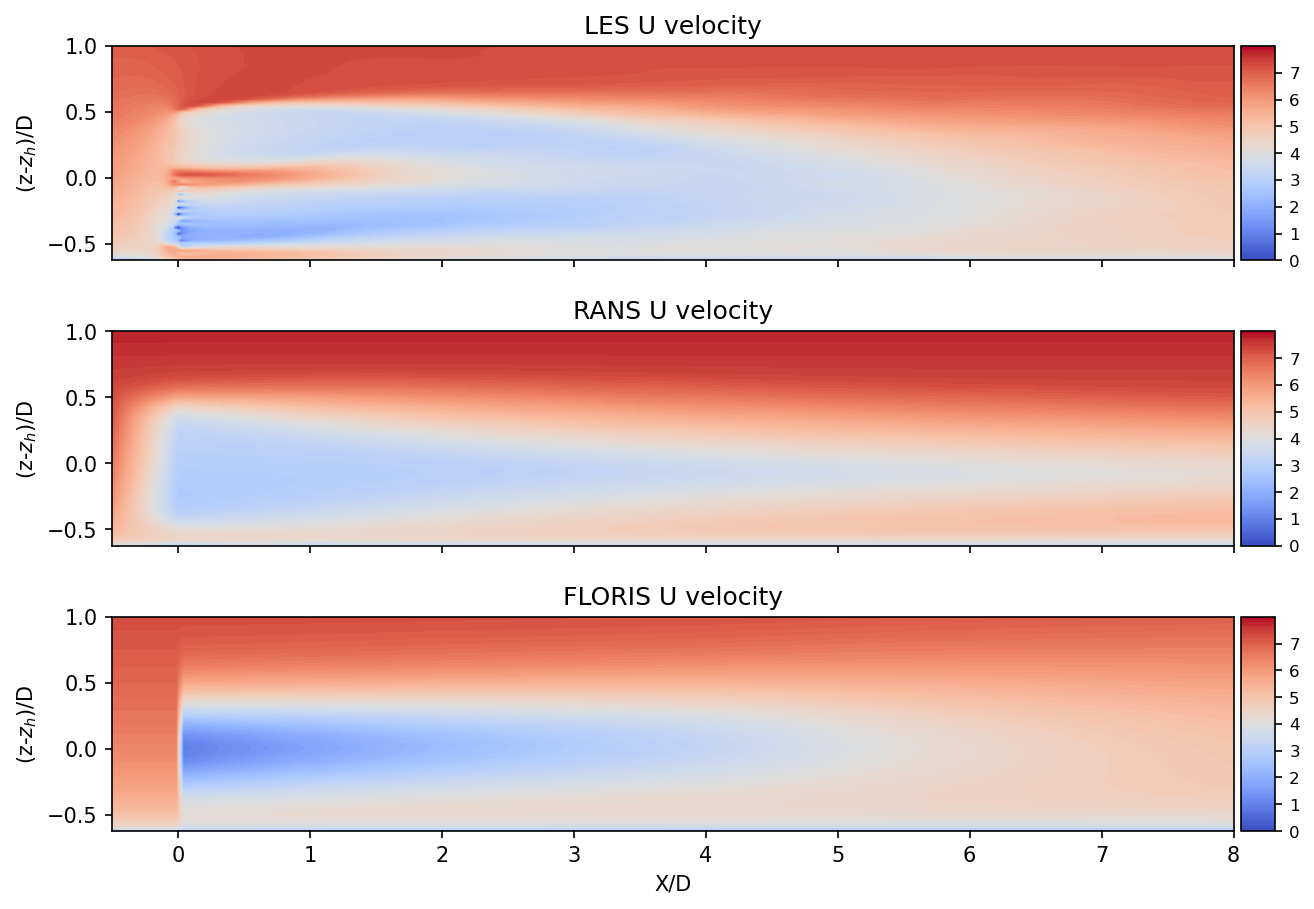

In [18]:
zvec=params['zm'][0,:]
yvec=params['ym'][:,0]
xm, zm = np.meshgrid(xvec, zvec)
iyRANS = find_nearest(yvec, 0.0)

# Compute flow slices
streamwise_plane = fmodel.calculate_y_plane(x_resolution=Nx,
                                            z_resolution=Nz,
                                            crossstream_dist=LES_turby,
                                            x_bounds=(0,prob_hi[0]),
                                            z_bounds=(0,prob_hi[2]),
                                           )
cut_plane = streamwise_plane
xmF = np.array(cut_plane.df.x1).reshape((Nz, Nx))
zmF = np.array(cut_plane.df.x2).reshape((Nz, Nx))
umF = np.array(cut_plane.df.u).reshape((Nz, Nx))
xvecFLO = xmF[0,:]
zvecFLO = zmF[:,0]

c={}
fig, axs = plt.subplots(3,1,figsize=(10,7), dpi=150, sharex=True)
c[0] = axs[0].contourf((XZ_wake['x'][0,:,:]-LES_turbx)/turbD, (XZ_wake['z'][0,:,:]-turbhh)/turbD, XZ_wake['velocityx_avg'][0,:,:], levels=vlevels[plotv]['levels'], cmap='coolwarm')
c[1] = axs[1].contourf((xm-RANS_turbx)/turbD, (zm-turbhh)/turbD, phi[plotv][:,iyRANS,:].transpose(), levels=vlevels[plotv]['levels'], cmap='coolwarm')
c[2] = axs[2].contourf((xmF-LES_turbx)/turbD, (zmF-turbhh)/turbD,                               umF, levels=vlevels[plotv]['levels'], cmap='coolwarm')


for ix, ax in enumerate(axs):
    ax.set_xlim([-0.5,8])
    ax.set_ylim([-0.625, 1.0])
    ax.set_aspect('equal')
    
    divider = make_axes_locatable(axs[ix])
    cax = divider.append_axes("right", size="3%", pad=0.05)
    cbar=fig.colorbar(c[ix], ax=axs[ix], cax=cax, ticks = matplotlib.ticker.FixedLocator(vlevels[plotv]['cbarticks']))
    cbar.ax.tick_params(labelsize=8)
    
    ax.set_ylabel(r'(z-$z_h$)/D')

axs[2].set_xlabel('X/D')
axs[0].set_title('LES U velocity')
axs[1].set_title('RANS U velocity')
axs[2].set_title('FLORIS U velocity')

187 238.3166332665328
205 480.72144288577147
241 965.5310621242484
276 1436.8737474949899
312 1921.6833667334668


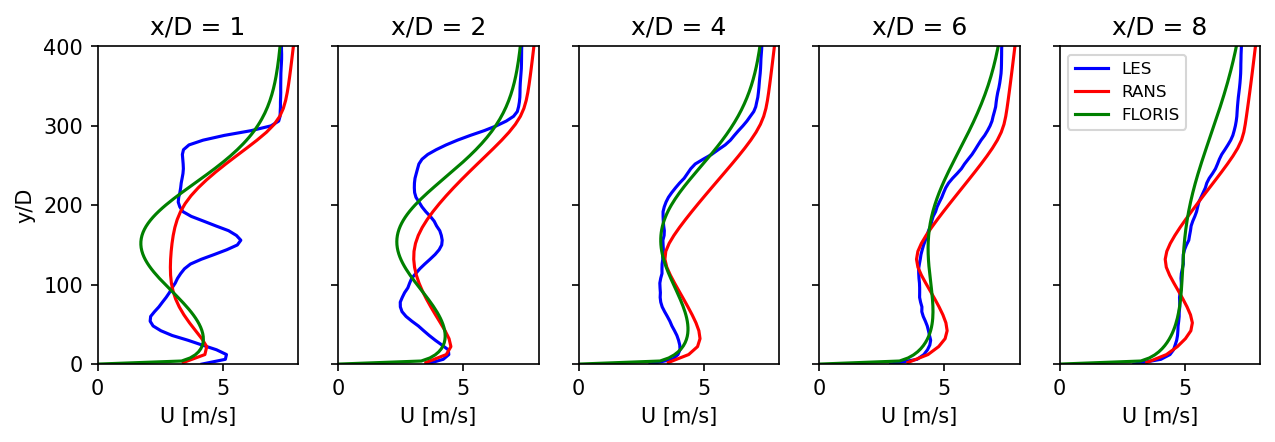

In [19]:
# Plot XY wake profiles
xvecLES = XZ_wake['x'][0,0,:]
zvecLES = XZ_wake['z'][0,:,0]


xplot = [1, 2, 4, 6, 8]
fig, axs = plt.subplots(1,len(xplot),figsize=(len(xplot)*2,2.75), dpi=150, sharey=True)
for ix, x in enumerate(xplot):
    axs[ix].set_title(f'x/D = {x}')
    # Plot LES
    ixLES = find_nearest((xvecLES-LES_turbx)/turbD, x)
    u_LES = XZ_wake['velocityx_avg'][0,:,ixLES]
    axs[ix].plot(u_LES, zvecLES, 'b-', label='LES')

    # Plot RANS
    ixRANS = find_nearest((xvec-RANS_turbx)/turbD, x)
    iyRANS = find_nearest(yvec, 0.0)
    u_RANS = phi['u'][ixRANS,iyRANS,:]
    axs[ix].plot(u_RANS, zvec, 'r-', label='RANS')

    # Plot FLORIS
    ixFLO = find_nearest((xvecFLO-LES_turbx)/turbD, x)
    print(ixFLO, xvecFLO[ixFLO]-LES_turbx)
    u_FLO = umF[:,ixFLO]
    axs[ix].plot(u_FLO, zvecFLO, 'g-', label='FLORIS')
    

for ax in axs:
    ax.set_xlim([0,8])
    ax.set_ylim([0, 400])
    ax.set_xlabel('U [m/s]')
axs[0].set_ylabel('y/D')
axs[-1].legend(fontsize=8)